# Calibration of modular detectors using Debye-Scherrer rings

Large pixel detectors are not monolithic: they are assembled from individual modules, each of
them nearly perfect since produced by lithography, but positioned with the tolerance of a
mechanical assembly. The resulting misalignments are small — a fraction of a pixel — yet they
are large enough to show up as steps in the position of the powder rings at the module
boundaries, and to limit the accuracy of any strain measurement performed with such a detector.

The usual way to characterize this distortion is to image a calibration object, typically a
metal plate drilled with a grid of holes. This has two limitations: the machining tolerance of
the object itself, and the fact that the grid only samples the distortion at its nodes, which
restricts the correction to its low-frequency components.

The method demonstrated in this tutorial replaces the grid by the diffraction signal itself.
Debye-Scherrer rings are continuous, they are recorded through the very same optical path as
the data, and they cover the whole surface of the detector: this gives access to all spatial
frequencies of the distortion. Several images are recorded with different beam-center
positions, so that every module sees rings at various places, and a single least-squares fit
refines simultaneously the position of every module (2 translations and 1 rotation each) and
the experimental geometry of every image.

Developed initially by Jonathan P. Wright, Carlotta Giacobbe and Eleanor Lawrence Bright from
ESRF-ID11 in https://doi.org/10.3390/cryst12020255, the method is applied here to the Eiger2
CdTe 4M of ID11, and its outcome is compared with the tabulated geometry of the detector and
with the geometry measured from a grid of holes.

Images can be obtained from:
https://www.silx.org/pub/pyFAI/detector_calibration/Eiger2-ID11/CeO2_Spatial_distortion_apr2021.tar.gz
In this tutorial, we start from the control-points used for calibrating the detector position for all 4
geometries, using for instance `pyFAI-calib2` on each of the 4 images available in the archive.
Once the geometry optained with good confidence, return to the third tab called "Peak picking". 
Select and click "Extract all rings". 
Tune the "Number of peaks per degree" as high as the quality of your data permits, stop when out-of-ring control-point get picked.
For this tutorial, control points and PONIs needs to be saved in files with the same basename, respectively in the third and fith tab of `pyFAI-calib2`).

In [1]:
%matplotlib inline

In [2]:
import glob
import os
import time
from matplotlib.pyplot import subplots
from IPython.display import Markdown
import numpy
import pyFAI
from pyFAI.gui import jupyter
from pyFAI.control_points import ControlPoints
from pyFAI.goniometer import SingleGeometry
from pyFAI.detectors.multi_module import MultiModuleRefinement
from pyFAI.utils.grid import Kabsch
print(f"Using pyFAI version {pyFAI.version}")
start_time = time.perf_counter()

Using pyFAI version 2026.9.0


In [3]:
ponis = glob.glob("*.poni")
ponis.sort()
cpf = glob.glob("*.npt")
cpf.sort()
tabulated_detector = pyFAI.detector_factory("Eiger2_CdTe_4M")
print("Control-points files: "+ ", ".join(cpf))
print("Total number of control-points: ", sum( len(ControlPoints(c).getListRing()) for i, c in enumerate(cpf)))

Control-points files: geom_0001.npt, geom_0002.npt, geom_0003.npt, geom_0004.npt
Total number of control-points:  62136


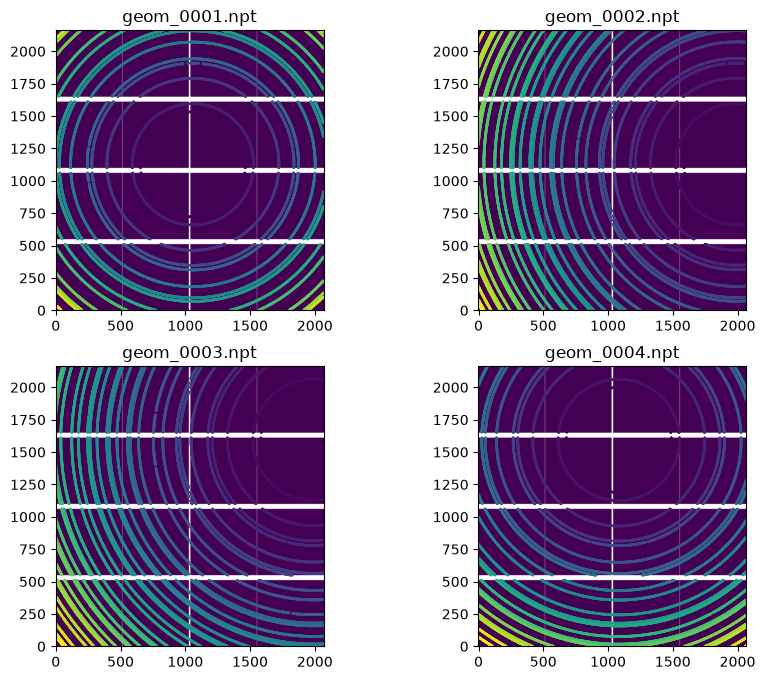

In [4]:
fig, ax = subplots(2,2, figsize=(10,8))

shape = pyFAI.load(ponis[0]).detector.shape
for i, c in enumerate(cpf):
    img = numpy.zeros(tabulated_detector.shape)
    img[tabulated_detector.mask>0] = numpy.nan
    cp = ControlPoints(c)
    y, x, n = numpy.array(cp.getList()).T
    ax[i//2, i%2].imshow(img, origin="lower")
    ax[i//2, i%2].set_title(c)
    ax[i//2, i%2].scatter(x, y, 1, c=n)

The four calibration images, with their control points colored by ring index: the beam center
moves from one image to the next, so that each block of pixels sees rings at different places.

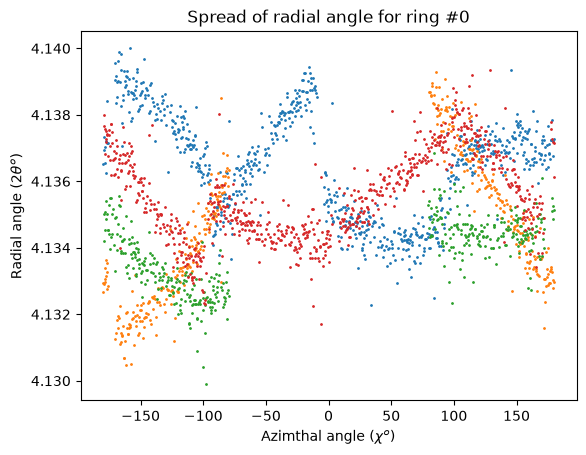

In [5]:
# Visualization of the need for calibration of module position
ring_idx = 0# 15

fig,ax = subplots()
for i, (c,p) in enumerate(zip(cpf, ponis)):
    ai = pyFAI.load(p)
    cp = pyFAI.control_points.ControlPoints(c)
    ring = numpy.array([(d[0], d[1]) for d in cp.getListRing() if d[2] == ring_idx])
    d0, d1 = ring.T
    tth = numpy.rad2deg(ai.tth(d0, d1))
    chi = numpy.rad2deg(ai.chi(d0, d1))
    ax.scatter(chi, tth, s=1)
ax.set_xlabel(r"Azimthal angle ($\chi ^o$)")
ax.set_ylabel(r"Radial angle (2$\theta ^o$)")
ax.set_title(f"Spread of radial angle for ring #{ring_idx}");

The same ring, seen through the nominal geometry of the detector, does not sit at a constant
radial angle: the 2θ position of the control points of ring #0 jumps by a few millidegrees
from one azimuthal sector to the next. Those steps occur at the module boundaries and are
precisely what the module refinement is meant to remove — the same plot is drawn again at the
end of this notebook, for the three descriptions of the detector.

## The Eiger2 4M is made of 4×4 blocks of pixels

The detector is physically assembled from 2×4 modules, but each of them is split in two halves
by a 2-pixel gap: this gives 4×4 blocks of pixels, which are the elements whose position is
refined here. They are labelled from 1 to 16 by `ndimage.label` on the mask of the detector.

MultiModule with 16 modules:
   1: Module centered at (256.0, 256.5).
   2: Module centered at (256.0, 771.5).
   3: Module centered at (256.0, 1296.5).
   4: Module centered at (256.0, 1811.5).
   5: Module centered at (806.0, 256.5).
   6: Module centered at (806.0, 771.5).
   7: Module centered at (806.0, 1296.5).
   8: Module centered at (806.0, 1811.5).
   9: Module centered at (1356.0, 256.5).
  10: Module centered at (1356.0, 771.5).
  11: Module centered at (1356.0, 1296.5).
  12: Module centered at (1356.0, 1811.5).
  13: Module centered at (1906.0, 256.5).
  14: Module centered at (1906.0, 771.5).
  15: Module centered at (1906.0, 1296.5).
  16: Module centered at (1906.0, 1811.5).


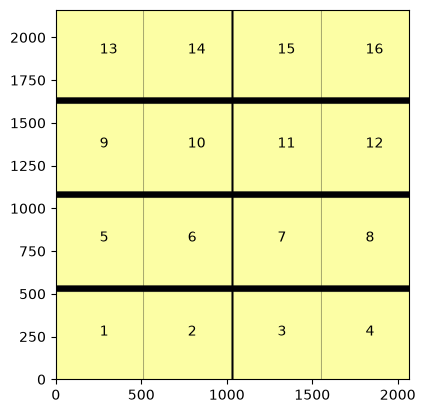

In [6]:
# This is the detector used on ID11
detector = pyFAI.detector_factory("Eiger2_CdTe_4M")
mm = MultiModuleRefinement.from_detector(detector)
ax = jupyter.display(1-detector.mask)
for i,j  in mm.modules.items():
    ax.annotate(str(i), [float(k.ravel()[0]) for k in j.center[-1::-1]])
print(mm)

In [7]:
# Let all modules free, except #6 which is close to the center.

for i,j  in mm.modules.items():    
    if i==6:
        mm.modules[i].fixed = True
    print(f"Module #{i:2d} {'fixed' if j.fixed else 'free'}")

Module # 1 free
Module # 2 free
Module # 3 free
Module # 4 free
Module # 5 free
Module # 6 fixed
Module # 7 free
Module # 8 free
Module # 9 free
Module #10 free
Module #11 free
Module #12 free
Module #13 free
Module #14 free
Module #15 free
Module #16 free


## Calibration of the detector

Special care must be taken to obtain sub-pixel precision:
* Use a good calibrant providing thin rings ($\rm CeO_2$ 0.25µm crystalite size)
* Use a monochromatic beam (55 keV)
* Use a small beam (200 µm)
* Use a fine capillary (500 µm) of non-absorbing material (kapton)
* Rotate the capillary (360°)
* Every single module of the detector should see at least one ring on each image
* Several beam-center positions should be used, ideally one in the center of the detector and in the four corners
* The detector should be far enough from the sample so that parallax effects are negligible
* Collect very intense rings to be able to extract many control points precisely.
* Control points should not be taken on the "double pixel", so addapt the mask accordingly.

**Now let us load the geometries together with their associated control points:**

In [8]:
for i in zip(cpf, ponis):
    print(f"Loading Geometry: `{i[1]}` with control points: ", end="")
    mm.load_control_points(*i, verbose=True)    
print("Number of parameters to refine (modules + configurations): ", mm.nb_param)

Loading Geometry: `geom_0001.poni` with control points: `geom_0001.npt`: CeO2 Calibrant with 769 reflections at wavelength 2.2543e-11
+------+------+
|Module|Points|
+------+------+
|     1|   869|
|     2|  1010|
|     3|   979|
|     4|   848|
|     5|   983|
|     6|   424|
|     7|   438|
|     8|   841|
|     9|   961|
|    10|   441|
|    11|   449|
|    12|   809|
|    13|   859|
|    14|   917|
|    15|   899|
|    16|   865|
+------+------+
Loading Geometry: `geom_0002.poni` with control points: `geom_0002.npt`: CeO2 Calibrant with 769 reflections at wavelength 2.2543e-11
+------+------+
|Module|Points|
+------+------+
|     1|  1565|
|     2|  1276|
|     3|   887|
|     4|   975|
|     5|  1675|
|     6|  1135|
|     7|   786|
|     8|   412|
|     9|  1630|
|    10|  1148|
|    11|   771|
|    12|   400|
|    13|  1561|
|    14|  1278|
|    15|   845|
|    16|   858|
+------+------+
Loading Geometry: `geom_0003.poni` with control points: `geom_0003.npt`: CeO2 Calibrant with

In [9]:
param = mm.init_param()
print("`param` is the concatenation of the displacement of the modules (45 values) and the 4 (geometries) x 5 poni-parameters") 
print(param)
print("Or in a better representation:")
mm.print_param()

`param` is the concatenation of the displacement of the modules (45 values) and the 4 (geometries) x 5 poni-parameters
[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.42051061  0.08519858  0.07923709
 -0.00045326 -0.0014653   0.42058144  0.08531912  0.14839767 -0.00229473
 -0.00143057  0.42075994  0.12025968  0.14827869 -0.00224953 -0.00138334
  0.42071487  0.11996403  0.08088361 -0.00096251 -0.00097806]
Or in a better representation:
module # 1: d0   = 0.0, d1   = 0.0, rot  = 0.0,
module # 2: d0   = 0.0, d1   = 0.0, rot  = 0.0,
module # 3: d0   =

In [10]:
mm.init_q_theo()

Both the 45 parameters describing the displacement of the modules and the 4 sets of PONI-parameters are refined at once.

In [11]:
%time res = mm.refine(param, method="lm")

CPU times: user 27.3 s, sys: 110 ms, total: 27.4 s
Wall time: 2.66 s


In [12]:
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 4.201e-03  4.815e-03 ...  1.349e-02 -5.571e-03]
           x: [ 3.585e-01 -4.564e-01 ... -1.430e-03 -1.251e-03]
        cost: 1.7069226713085581
         jac: [[ 0.000e+00 -0.000e+00 ... -0.000e+00 -0.000e+00]
               [ 0.000e+00 -0.000e+00 ... -0.000e+00 -0.000e+00]
               ...
               [-3.676e-02 -2.445e-02 ... -1.522e+02  2.292e+02]
               [-3.736e-02 -2.353e-02 ... -1.465e+02  2.329e+02]]
        grad: [ 6.272e-07 -1.817e-06 ... -1.642e-06 -1.185e-06]
  optimality: 4.504614707911969e-06
 active_mask: [0 0 ... 0 0]
        nfev: 4
        njev: None
 chi2_before: 0.00010871623083245781
  chi2_after: 5.494150480586321e-05
     applied: True

In [13]:
# Precision of the fit, from the jacobian of the residuals:
sigma = mm.calc_uncertainties(res)
mm.print_param(res.x, sigma)

module # 1: d0   =  0.358486 ± 0.020636, d1   = -0.456418 ± 0.019417, rot  =  0.000954 ± 0.000028,
module # 2: d0   = -0.139337 ± 0.009246, d1   = -0.503791 ± 0.015935, rot  =  0.000844 ± 0.000026,
module # 3: d0   = -0.293870 ± 0.010414, d1   = -0.404383 ± 0.015934, rot  =  0.000216 ± 0.000026,
module # 4: d0   = -0.422150 ± 0.019388, d1   = -0.435937 ± 0.018250, rot  =  0.000323 ± 0.000028,
module # 5: d0   = -0.107558 ± 0.018163, d1   = -0.359814 ± 0.008214, rot  = -0.000020 ± 0.000027,
module # 6: Fixed
module # 7: d0   =  0.123252 ± 0.010296, d1   = -0.399504 ± 0.007484, rot  = -0.000831 ± 0.000028,
module # 8: d0   = -0.297001 ± 0.019260, d1   = -0.543292 ± 0.009200, rot  =  0.000384 ± 0.000029,
module # 9: d0   =  0.084110 ± 0.019106, d1   = -0.325008 ± 0.010226, rot  =  0.000330 ± 0.000027,
module #10: d0   = -0.057456 ± 0.010772, d1   = -0.044165 ± 0.010142, rot  =  0.000462 ± 0.000029,
module #11: d0   = -0.120670 ± 0.011741, d1   = -0.161691 ± 0.010680, rot  =  0.000591 ± 0.

In [14]:
print(f"Improvement of refined cost from {mm.cost(param)} --> {mm.cost(res.x)}")

Improvement of refined cost from 6.755191719005598 --> 3.4138453426171163


## Saving the refined detector

`MultiModule.to_detector` applies the displacement of every module to the corners of the
pixels of the tabulated detector and returns a `Detector` object where the position of the
4 corners of each pixel is stored explicitly. This is the only way to describe a detector
which is neither uniform nor contiguous, and the NeXus format is the only one able to store
it. Such a file is read back with `pyFAI.detector_factory` and used like any other detector,
for example in a poni-file.

In [15]:
# Build a detector from the displaced modules:
refined_detector = mm.to_detector()

### Removing the arbitrary rigid motion

The refinement constrains the *relative* position of the modules, not the position of the
detector as a whole: a global translation and rotation of all the modules is exactly
compensated by the poni-parameters of the four geometries. Fixing module #6 removes this
singularity but leaves the whole pixel grid shifted with respect to the tabulated detector,
which makes the refined values hard to interpret and the resulting poni-files hard to
compare.

The `Kabsch` algorithm provides the rigid transformation — one rotation and one translation —
which brings the refined pixel grid as close as possible to the tabulated one, in the
least-squares sense. Applying it does not change the shape of the detector, hence neither the
quality of the calibration, it only removes the arbitrary part of the solution.

In [16]:
# Re-center pixels so that they are as close as possible to the tabulated detector
pixel = tabulated_detector.pixel1
pixel_coord_tab = tabulated_detector.get_pixel_corners().astype(numpy.float64)
pixel_coord_pow = refined_detector.get_pixel_corners().astype(numpy.float64)
displ_refined = numpy.sqrt(((pixel_coord_pow - pixel_coord_tab)**2).sum(axis=-1))/pixel

kabsch = Kabsch(pixel_coord_tab.reshape((-1, 3)), pixel_coord_pow.reshape((-1, 3)))
print(kabsch)
pixel_coord_cen = kabsch.correct(pixel_coord_pow.reshape((-1, 3))).reshape(pixel_coord_tab.shape)
displ_aligned = numpy.sqrt(((pixel_coord_cen - pixel_coord_tab)**2).sum(axis=-1))/pixel

Rigid transformation of angle -0.000° and translation [[ 0.00000000e+00 -1.37682783e-05  3.73835678e-05]], RMSD=0.000017


Maximum displacement, before: 0.92, after: 0.68


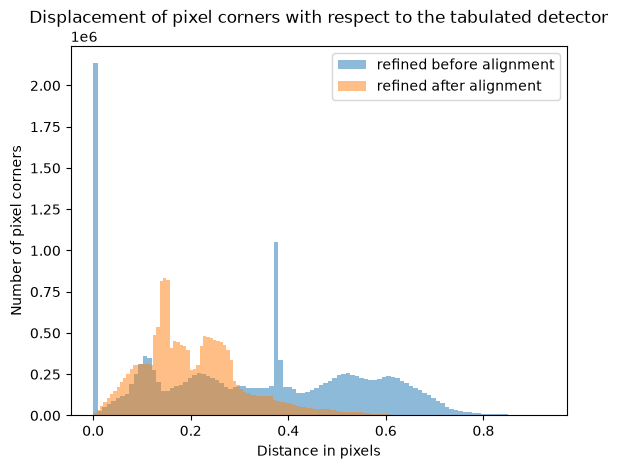

In [17]:
fig, ax = subplots()
ax.hist(displ_refined.ravel(), 100, label="refined before alignment", alpha=0.5)
ax.hist(displ_aligned.ravel(), 100, label="refined after alignment", alpha=0.5)
ax.set_title("Displacement of pixel corners with respect to the tabulated detector")
ax.set_xlabel("Distance in pixels")
ax.set_ylabel("Number of pixel corners")
ax.legend();
print(f"Maximum displacement, before: {displ_refined.max():.2f}, after: {displ_aligned.max():.2f}")

Before the alignment, the histogram shows the deformation of the detector itself, module by
module: module #6 is exactly at zero since it was kept fixed during the refinement, and the
other modules are spread according to how far they sit from it. After the alignment, every
module has moved — module #6 included — but the mean displacement with respect to a regular
pixel layout is as small as it can be. Here the rigid motion removed is almost a pure
translation of half a pixel, and the maximum displacement drops from 0.92 to 0.68 pixel.

In [18]:
detector_file = "Eiger2CdTe_4M_ID11_powder.h5"
if os.path.exists(detector_file):
    os.remove(detector_file)
refined_detector.set_pixel_corners(pixel_coord_cen)
refined_detector.save(detector_file)
print(f"{detector_file}: {os.stat(detector_file).st_size/1e6:.1f} MB")
print(pyFAI.detector_factory(detector_file))

Eiger2CdTe_4M_ID11_powder.h5: 12.5 MB


Detector detector from NeXus file: Eiger2CdTe_4M_ID11_powder.h5	 PixelSize= 75µm, 75µm	 BottomRight (3)


## Validation of the method

Three descriptions of the very same detector are now compared:

* **Tabulated**: the nominal geometry of the `Eiger2 CdTe 4M` as distributed with pyFAI,
  where all modules are assumed to be perfectly aligned on a regular grid;
* **Grid of holes**: the geometry measured from the image of a grid-shaped mask, obtained
  in the [Eiger2-ID11](../Eiger_Calibration/Eiger2-ID11_grid.ipynb) tutorial for this very
  detector;
* **Powder rings**: the geometry refined in this notebook.

Each of them is used to calibrate the 4 images, independently from each other: the very
same control points are used, the refinement starts from the same poni-files, and both the
`wavelength` (known from the monochromator) and `rot3` are kept fixed. The residual error of
the calibration, i.e. the root mean square deviation between the measured position of the
rings and the expected one, then measures how well the detector is described: the better
the description, the smaller the residual.

In [19]:
def calibration_residuals(detector, fix=("wavelength", "rot3")):
    """Calibrate every image with a given detector and return the residual errors

    :param detector: the detector geometry to be validated
    :param fix: name of the parameters which are kept fixed during the refinement
    :return: list with the rms deviation to the expected ring position, in millidegree
    """
    residuals = []
    grs = {}
    for npt, poni in zip(cpf, ponis):
        cp = ControlPoints(npt)
        sg = SingleGeometry(npt, control_points=cp, calibrant=cp.calibrant,
                            detector=detector, geometry=poni)
        gr = sg.geometry_refinement
        gr.refine3(fix=list(fix))
        residuals.append(1000 * numpy.rad2deg(numpy.sqrt(gr.chi2() / gr.data.shape[0])))
        grs[os.path.basename(poni)] = gr
    return residuals, grs


grid_file = "../Eiger_Calibration/Eiger2CdTe_4M_ID11_grid.h5"  # produced by the Eiger2-ID11 tutorial
validated = {"Tabulated": pyFAI.detector_factory("Eiger2_CdTe_4M")}
if os.path.exists(grid_file):
    validated["Grid of holes"] = pyFAI.detector_factory(grid_file)
else:
    print(f"`{grid_file}` is missing: run the Eiger2-ID11 tutorial to build it")
validated["Powder rings"] = pyFAI.detector_factory(detector_file)

%time residuals = {name: calibration_residuals(det) for name, det in validated.items()}

CPU times: user 51min 45s, sys: 5.22 s, total: 51min 50s
Wall time: 1min 1s


In [20]:
# Residual error of the calibration, image per image:

header = [os.path.splitext(i)[0] for i in cpf]
table = ["| Detector | " + " | ".join(header) + " | Mean |",
         "|:---|" + "---:|" * (len(header) + 1)]
for name, values in residuals.items():
    table.append(f"| {name} | " + " | ".join(f"{v:.3f}" for v in values[0]) +
                 f" | **{numpy.mean(values[0]):.3f}** |")
Markdown("Residual error of the calibration, in millidegree ($2\\theta$):\n\n" + "\n".join(table))

Residual error of the calibration, in millidegree ($2\theta$):

| Detector | geom_0001 | geom_0002 | geom_0003 | geom_0004 | Mean |
|:---|---:|---:|---:|---:|---:|
| Tabulated | 1.808 | 2.264 | 2.424 | 1.960 | **2.114** |
| Grid of holes | 1.300 | 1.886 | 2.097 | 1.404 | **1.672** |
| Powder rings | 0.943 | 1.734 | 1.931 | 1.091 | **1.425** |

The three descriptions are ranked as expected: any measured geometry beats the nominal one,
where the modules are assumed to be perfectly aligned on a regular grid. 
The powder rings even perform slightly better than the grid of holes, which is consistent with the original
publication — and this without requiring any dedicated calibration object.

### Visual validation of the correction

Here we present side-by-side the spread for a single ring before and after the correction with the different detector models:

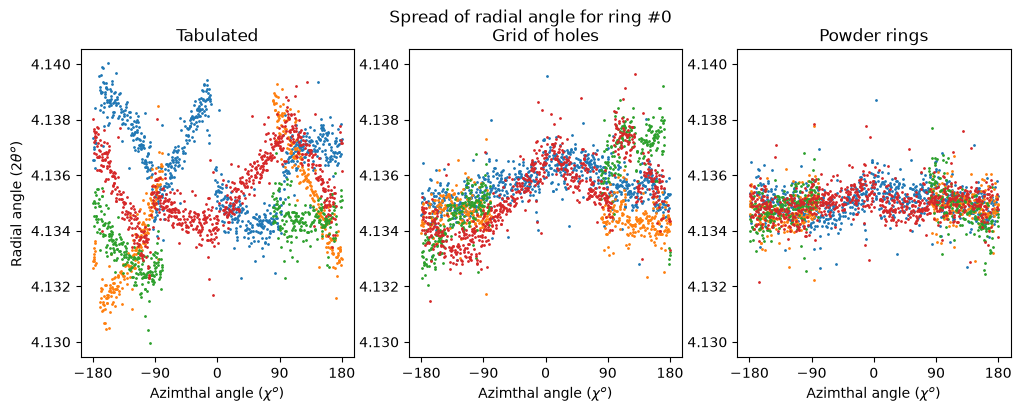

In [21]:
# Visualization of a ring spread
ring_idx = 0# 15
fig, ax = subplots(1,3, figsize=(12,4))
for a,k in zip(ax, residuals):
    for i, gr in enumerate(residuals[k][1].values()):
        ring = numpy.array([(d[0], d[1]) for d in gr.data if d[2] == ring_idx])
        # print(len(ring))
        d0, d1 = ring.T
        tth = numpy.rad2deg(gr.tth(d0, d1))
        chi = numpy.rad2deg(gr.chi(d0, d1))
        a.scatter(chi, tth, s=1)
        a.set_title(k)
        a.set_xticks([-180, -90, 0, 90, 180])

ax[0].set_xlabel(r"Azimthal angle ($\chi ^o$)")
ax[1].set_xlabel(r"Azimthal angle ($\chi ^o$)")
ax[2].set_xlabel(r"Azimthal angle ($\chi ^o$)")
ax[0].set_ylabel(r"Radial angle (2$\theta ^o$)")
ax[1].set_ylim(ax[0].get_ylim())
ax[2].set_ylim(ax[0].get_ylim())
fig.suptitle(f"Spread of radial angle for ring #{ring_idx}");  #noqa: E703

## Conclusion

The method described by Wright *et al.* is now available in pyFAI, in the
`pyFAI.detectors.multi_module` module: the position of the 16 modules of the Eiger2 CdTe 4M
(45 parameters, one module being fixed to remove the singularity of the problem) is refined
together with the geometry of the 4 powder patterns (4 × 5 parameters), i.e. 65 parameters in
total, from the ~62000 control points extracted from the images of a $\rm CeO_2$ capillary.
The result is converted into a `Detector` object which holds the position of the 4 corners of
every pixel and is saved as a NeXus file: it can then be used anywhere in pyFAI, in a
poni-file, for azimuthal integration or in `pyFAI-calib2`.

**The choice of the optimizer matters more than anything else here.** With 65 parameters, a
Nelder-Mead simplex stops in a local minimum: it needs more than 3 minutes and leaves the
translations of the modules below $10^{-3}$ pixel, i.e. essentially at their initial value. A
least-squares optimizer sees the *vector* of residuals instead of its sum and takes advantage
of its derivatives: `refine(param, method="lm")` divides the cost by two in less than three
seconds, and the `trf` and `dogbox` algorithms converge towards the very same solution.
The refined module positions then become physically meaningful: with respect to a perfectly
regular pixel grid, and once the arbitrary rigid motion has been removed, the corners of the
pixels are displaced by up to 0.68 pixel, the individual modules being rotated by up to
1.13 mrad — the same order of magnitude as the values published for this very detector
(module shifts of 0.16 pixel and rotations of 0.42 mrad on average, 1.1 mrad at most).

The validation performed above measures how well the detector is described by the residual
error left after calibrating each image: 2.11 m° with the tabulated detector, 1.68 m° with the
grid of holes and 1.43 m° with the geometry refined here. These values are to be compared with
the angle subtended by a single pixel, 10.2 m° at 42 cm: the calibration is accurate to about
a seventh of a pixel, and describing the position of the modules from the powder rings gains
33% on the residual — 15% better than what the grid of holes provides, at a much lower
experimental cost since no dedicated calibration object is needed.

The precision claimed in the original publication, 1/350 pixel on the module positions, is
still not reached: the jacobian of the fit gives a standard deviation of 0.015 pixel on the
translations and 29 µrad on the rotations, about one order of magnitude above the published
values. Two directions remain open to improve this:

* **Number and quality of the control points.** The 62000 points used here are 3.6 times
  fewer than the 223184 peaks of the publication, where a peak is fitted along every single
  row and every single column of every module. This accounts for a factor 2 on the
  uncertainties, the rest coming from the precision of each individual peak position — which
  is also where the recent correction of the sub-pixel refinement paid off: the uncertainties
  dropped by a factor 2.6 while the number of points only grew by 2.6, i.e. faster than the
  square root of the statistics.
* **Data collection.** Only 4 beam-center positions were used. The recommendations listed at
  the beginning of this notebook, in particular having every module see several
  image, are the cheapest way to improve the conditioning of the problem.

In [22]:
print(f"Total execution time: {time.perf_counter() - start_time:.3f}s")

Total execution time: 80.768s
